# **Electrical Load Forecasting**

## Project Overview

This project focuses on electrical load forecasting using the **Savona Campus power consumption dataset**. The dataset contains electrical load data collected from 2018 to 2023 with a time interval of one minute. Load forecasting is an important task in energy management because it helps predict future electricity demand and supports efficient operation of power systems.

## Project Objective

* Analyze the campus electrical load dataset.
* Perform data cleaning and preprocessing.
* Explore patterns and trends in electricity consumption.
* Apply forecasting methods to predict future load demand.
* Compare forecasting performance using evaluation metrics.
* Understand how machine learning and time series methods can be used for load forecasting.



---



## **Imports and Data Loading**

In [37]:
!pip install xgboost lightgbm -q

import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from collections import Counter
import re
import calendar
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.dates as mdates
import matplotlib.patheffects as pe

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Loading Data**

- Dataset is uploaded into Google Drive, and read from there

In [2]:
# Google Drive direct download link
file_id = "1upFzClKUat52MfyVv_QoKXWq5QK7vU5J"

url = f"https://drive.google.com/uc?id={file_id}"

In [3]:
# Load CSV
df = pd.read_csv(url)

## **Data Preprocessing**

Steps included:
1. Date-Time Standardization
2. Negative Value Management
3. Missing Value Imputation
4. Resolving Timestamp Deduplication
5. Handeling Missing Timestamps
6. Periodic Resampling




**Data Inspection**

**1.**   Checking dataset shape, columns and first rows


In [4]:
# Dataset shape
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (2809602, 2)

Column names:
Index(['data_timestamp', 'value'], dtype='object')

First 5 rows:


,data_timestamp,value
0,2017-12-31 23:00:00,89.467247
1,2017-12-31 23:01:00,93.805466
2,2017-12-31 23:02:00,93.805466
3,2017-12-31 23:03:00,88.202477
4,2017-12-31 23:04:00,88.202477


**2.a. Identifying Different Formats in Date-Time**


In [5]:
# Take timestamp column as string
timestamps = df['data_timestamp'].astype(str)

# Function to classify timestamp format
def detect_format(ts):
    patterns = {
        "YYYY-MM-DD HH:MM:SS": r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$",
        "YYYY-MM-DD HH:MM:SS.milliseconds": r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+$",
        "YYYY/MM/DD HH:MM:SS": r"^\d{4}/\d{2}/\d{2} \d{2}:\d{2}:\d{2}$",
        "Other": r".*"
    }
    for name, pattern in patterns.items():
        if re.match(pattern, ts):
            return name

# Detect formats
format_counts = Counter(timestamps.apply(detect_format))
print("===== DETECTED TIMESTAMP FORMATS =====\n")
for fmt, count in format_counts.items():
    print(f"{fmt}: {count}")

===== DETECTED TIMESTAMP FORMATS =====

YYYY-MM-DD HH:MM:SS: 1028996
YYYY-MM-DD HH:MM:SS.milliseconds: 1780606


**2.b. Standard Timestamp Conversion:** Change all date formats into one single format.


In [6]:
print(f"data before conversion: {df['data_timestamp'].dtype}")

# Conversion of data type
df['data_timestamp'] = pd.to_datetime(
    df['data_timestamp'],
    format='mixed',
    errors='coerce'
)

# Round timestamps to nearest minute
df['data_timestamp'] = df['data_timestamp'].dt.floor('min')

# Check conversion result
print(f"data after conversion: {df['data_timestamp'].dtype}")

data before conversion: object
data after conversion: datetime64[ns]


**3.a. Identifying Negative Values**

> Electrical load/power consumption is expected to be non-negative. (load\>=0)

> Having negative values in dataset may show:
> - Sensor failure.
> - Meter calibration issues

> In forecasting projects, we usually inspect them before deciding whether to:
> - remove them
> - replace with NaN
> - replace with estimated values
> - keep them if physically meaningful

In [7]:
# DETECT NEGATIVE LOAD VALUES
negative_values = df[df['value'] < 0]
print("Number of negative values:", negative_values.shape[0])
print("\nSample negative values:")
display(negative_values.head())

Number of negative values: 55

Sample negative values:


,data_timestamp,value
277680,2018-07-13 12:19:00,-0.047
277681,2018-07-13 12:20:00,-0.047
277682,2018-07-13 12:21:00,-0.047
277683,2018-07-13 12:22:00,-0.047
277684,2018-07-13 12:23:00,-0.047


**3.b. Handle Negative Values:** Replace negative values with NaN instead of deleting rows
> Because deleting rows:
> - breaks time continuity
> - creates artificial gaps

> Using NaN preserves timestamps so we can later:
> - replace values
> - resample correctly

In [8]:
# Replace negative values with NaN
df.loc[df['value'] < 0, 'value'] = np.nan

# Count remaining negative values
negative_after = (df['value'] < 0).sum()

print("Negative values after cleaning:",
      negative_after)

Negative values after cleaning: 0


**4.a. Identifying Missing Values**

In [9]:
# Missing values
print("===== MISSING VALUES =====")
print(df.isna().sum())

===== MISSING VALUES =====
data_timestamp     0
value             55
dtype: int64


**4.b. Handle Missing Values:**  Estimates missing values based on neighboring points (**time interpolation**)
- Power usage changes smoothly and constantly over time
- If you suddenly remove or skip data points, it ruins the pattern and makes it harder to predict


In [10]:
# Interpolate missing values using time order
df['value'] = df['value'].interpolate(method='linear')

# Count remaining NaN values
nan_after = df['value'].isnull().sum()

print("NaN values after interpolation:",
      nan_after)

NaN values after interpolation: 0


**5.a. Identifying Duplicates**

> In forecasting datasets, each timestamp should represent:
> - one measurement
> - one load value
> - one time instant

> Duplicate timestamps indicate:
> - sensor recording errors
> - merged datasets
> - repeated measurements

> We inspect them before deciding whether to:
> - remove
> - average
> - keep
> - aggregate

In [11]:
# DETECT DUPLICATE ROWS
# This finds every "True Duplicate rows"—exact carbon copies (time and value)
duplicate_rows = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", duplicate_rows.shape[0])

print("\nSample duplicate rows:")
display(duplicate_rows.head())

Number of duplicate rows: 397

Sample duplicate rows:


,data_timestamp,value
259599,2018-06-30 23:00:00,97.513168
259600,2018-06-30 23:00:00,97.513168
271120,2018-07-08 23:00:00,102.683899
271121,2018-07-08 23:00:00,102.683899
694589,2019-05-19 23:00:00,76.417702


In [12]:
# DETECT DUPLICATE TIMESTAMPS
# This finds every instance where a timestamp appears more than once. (only time)
duplicate_timestamps = df[df['data_timestamp'].duplicated(keep=False)]

print("Number of rows with duplicate timestamps:",
      duplicate_timestamps.shape[0])

print("\nSample duplicate timestamps:")
display(
    duplicate_timestamps
    .sort_values('data_timestamp')
    .head(9))

Number of rows with duplicate timestamps: 971

Sample duplicate timestamps:


,data_timestamp,value
259599,2018-06-30 23:00:00,97.513168
259600,2018-06-30 23:00:00,97.513168
271120,2018-07-08 23:00:00,102.683899
271121,2018-07-08 23:00:00,102.683899
461060,2018-11-17 23:59:00,84.865021
461061,2018-11-17 23:59:00,88.264000
684508,2019-05-12 23:00:00,56.252289
684509,2019-05-12 23:00:00,71.164719
694589,2019-05-19 23:00:00,76.417702


**5.b. Handle Duplicate Timestamp:** Keep first occurrence of each timestamp

In [13]:
# Keep first occurrence of each timestamp
df = df.drop_duplicates(
    subset='data_timestamp',
    keep='first'
)

# Count duplicates after cleaning
duplicates_after = df['data_timestamp'].duplicated().sum()

print("Duplicate timestamps after cleaning:",
      duplicates_after)

print("\nNew dataset shape:")
print(df.shape)

Duplicate timestamps after cleaning: 0

New dataset shape:
(2809116, 2)


**6.a. Identifying Missing Timestamps**

In [14]:
# Make sure data is sorted by timestamp
df = df.sort_values('data_timestamp').copy()

# Calculate time difference between consecutive timestamps
df['time_diff'] = df['data_timestamp'].diff()

# Identify gaps larger than the expected 1-minute interval
gap_events = df[df['time_diff'] > pd.Timedelta(minutes=1)].copy()

print("Number of gap events larger than 1 minute:", gap_events.shape[0])

print("\nLargest gap events:")
display(
    gap_events[['data_timestamp', 'time_diff']]
    .sort_values('time_diff', ascending=False)
    .head()
)

Number of gap events larger than 1 minute: 4721

Largest gap events:


,data_timestamp,time_diff
757327,2019-09-30 22:00:00,61 days 00:01:00
676663,2019-05-06 15:19:00,15 days 04:40:00
713273,2019-06-21 09:17:00,13 days 02:56:00
717942,2019-07-04 13:35:00,9 days 22:30:00
707530,2019-06-04 06:39:00,6 days 08:01:00


In [15]:
# Create the expected complete 1-minute timestamp range
full_time_index = pd.date_range(
    start=df['data_timestamp'].min(),
    end=df['data_timestamp'].max(),
    freq='1min'
)

# Find timestamps that are expected but missing from the dataset
missing_timestamps = full_time_index.difference(df['data_timestamp'])

print("Expected number of 1-minute timestamps:", len(full_time_index))
print("Existing number of timestamps:", df['data_timestamp'].nunique())
print("Total missing 1-minute timestamps:", len(missing_timestamps))

print("\nFirst 5 missing timestamps:")
print(missing_timestamps[:5])

print("\nLast 5 missing timestamps:")
print(missing_timestamps[-5:])

Expected number of 1-minute timestamps: 2988584
Existing number of timestamps: 2809116
Total missing 1-minute timestamps: 179468

First 5 missing timestamps:
DatetimeIndex(['2018-02-14 08:10:00', '2018-02-14 08:11:00',
               '2018-02-14 08:12:00', '2018-02-14 08:13:00',
               '2018-02-14 08:14:00'],
              dtype='datetime64[ns]', freq=None)

Last 5 missing timestamps:
DatetimeIndex(['2023-09-04 18:18:00', '2023-09-04 18:19:00',
               '2023-09-04 18:20:00', '2023-09-04 18:21:00',
               '2023-09-04 18:22:00'],
              dtype='datetime64[ns]', freq=None)


**6.b. Handle Time Gaps:**

In [16]:
# Remove the helper column
if 'time_diff' in df.columns:
    df = df.drop(columns=['time_diff'])

# Set the index
df = df.set_index('data_timestamp')

# Reindex using the full_time_index
df = df.reindex(full_time_index)
df.index.name = 'data_timestamp'

print("Shape after inserting missing timestamps:", df.shape)
print("\nMissing values after inserting timestamps:\n", df.isnull().sum())

Shape after inserting missing timestamps: (2988584, 1)

Missing values after inserting timestamps:
 value    179468
dtype: int64


In [17]:
# HANDLE SHORT GAPS ONLY

print("NaN values before short-gap interpolation:", df['value'].isna().sum())

# Interpolate only short consecutive missing periods (up to 60 mins)
df['value'] = df['value'].interpolate(
    method='time',
    limit=60,
    limit_direction='both'
)

print("NaN values remaining from long gaps:", df['value'].isna().sum())

NaN values before short-gap interpolation: 179468
NaN values remaining from long gaps: 170103


In [18]:
# FILL NIGHT-TIME GAPS (23:00 to 07:00)

print("NaN values before night-fill:", df['value'].isna().sum())

# Night mask: 23:00 to 06:59
night_mask = (df.index.hour >= 23) | (df.index.hour < 7)

# Missing values mask
missing_mask = df['value'].isna()

# Forward fill with a maximum limit
# Example: fill at most 8 hours = 480 minutes
ffilled_values = df['value'].ffill(limit=480)

# Fill only missing night-time values
df.loc[night_mask & missing_mask, 'value'] = ffilled_values[night_mask & missing_mask]

print("NaN values after night-fill:", df['value'].isna().sum())
print("NaN values filled:", missing_mask.sum() - df['value'].isna().sum())

NaN values before night-fill: 170103
NaN values after night-fill: 166943
NaN values filled: 3160


In [19]:
# CHECK REMAINING LONG GAPS

# Create the mask
missing_mask = df['value'].isna()
missing_count = missing_mask.sum()

print("Remaining missing rows:", missing_count)

if missing_count > 0:
    # Group consecutive missing values together
    gap_groups = (missing_mask != missing_mask.shift()).cumsum()

    long_gap_summary = (
        df[missing_mask]
        .groupby(gap_groups[missing_mask])
        .apply(lambda x: pd.Series({
            'start_time': x.index.min(),
            'end_time': x.index.max(),
            'missing_minutes': len(x)
        }))
        .sort_values('missing_minutes', ascending=False)
    )

    print("\nLargest remaining long gaps:")
    display(long_gap_summary.head(5))

Remaining missing rows: 166943

Largest remaining long gaps:


,start_time,end_time,missing_minutes
value,,,
32,2019-08-01 07:00:00,2019-09-30 20:59:00,87240
18,2019-04-21 11:40:00,2019-05-06 14:18:00,21759
26,2019-06-08 07:22:00,2019-06-21 08:16:00,18775
30,2019-06-25 00:06:00,2019-07-04 12:34:00,13709
24,2019-05-29 07:00:00,2019-06-04 05:38:00,8559


In [20]:
# REMOVE REMAINING MISSING VALUES

print("Shape before removing remaining NaN rows:", df.shape)

# Drop rows where the value is still missing
df_clean = df.dropna(subset=['value']).copy()

print("Shape after removing remaining NaN rows:", df_clean.shape)
print("Remaining NaN values:", df_clean['value'].isna().sum())

Shape before removing remaining NaN rows: (2988584, 1)
Shape after removing remaining NaN rows: (2821641, 1)
Remaining NaN values: 0


**7. Resample Data to 15-minute Average**

In [21]:
# RESAMPLE DATA TO 15-MINUTE AVERAGE

print("Original cleaned dataset shape:", df_clean.shape)

# Resample to 15-minute average
df_15min = df_clean.resample('15min').mean()

print("15-minute dataset shape:", df_15min.shape)

print("\nFirst rows:")
display(df_15min.head())

Original cleaned dataset shape: (2821641, 1)
15-minute dataset shape: (199239, 1)

First rows:


,value
data_timestamp,
2017-12-31 23:00:00,91.015495
2017-12-31 23:15:00,89.464928
2017-12-31 23:30:00,88.188497
2017-12-31 23:45:00,87.694330
2018-01-01 00:00:00,90.413497


**8. Missing Values After Resampleing:** These missing values are remaining because of long gaps in dataset, and in this section we remove them.

In [22]:
# REMOVE MISSING VALUES AFTER 15-MIN RESAMPLING

print("Shape before removing missing 15-min rows:", df_15min.shape)
print("Missing values before removal:", df_15min['value'].isna().sum())

# Remove missing 15-minute rows
df_15min_clean = df_15min.dropna(subset=['value']).copy()

print("\nShape after removing missing 15-min rows:", df_15min_clean.shape)
print("Missing values after removal:", df_15min_clean['value'].isna().sum())

Shape before removing missing 15-min rows: (199239, 1)
Missing values before removal: 11107

Shape after removing missing 15-min rows: (188132, 1)
Missing values after removal: 0


✅**df_15min_clean** is cleaned and preprocessed dataset

## **Exploratory Data Analysis**

**1. Plot the 15-minute load time series** shows:
- overall trend over the years
- seasonal behavior

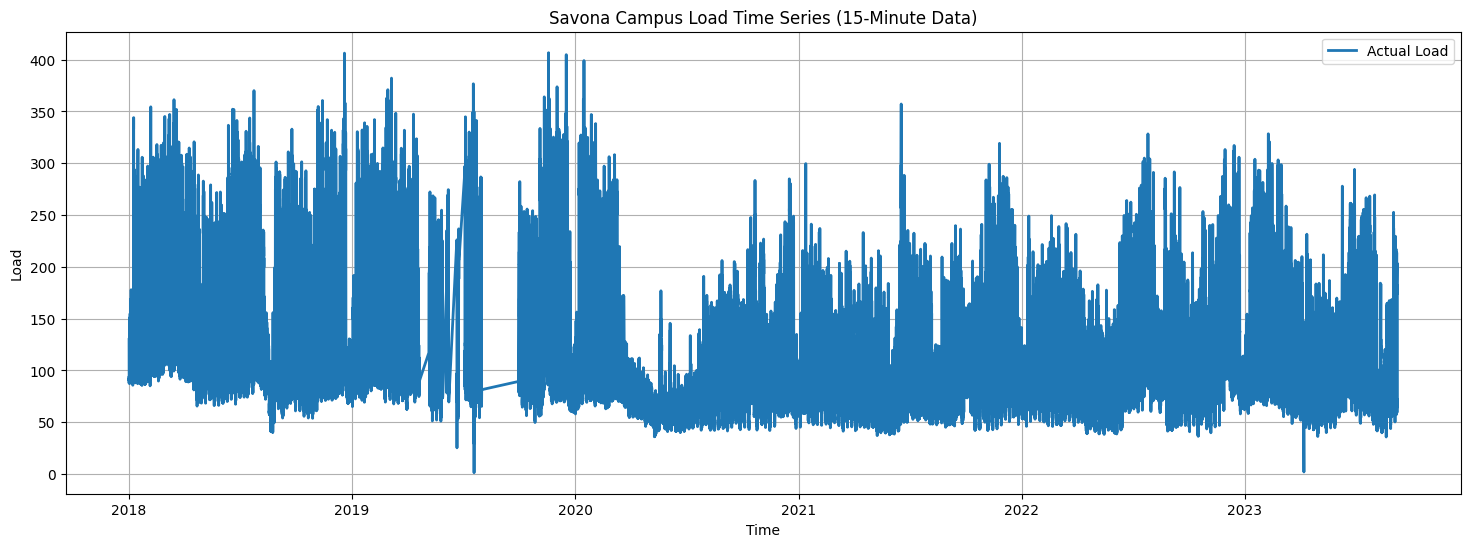

In [23]:
plt.figure(figsize=(18, 6))
# you can adjust number of data from dataset to be visualized.
# If you want to plot the whole dataset, N=-1
N = -1

plt.plot(
    df_15min_clean.index[:N],
    df_15min_clean['value'].iloc[:N],
    label='Actual Load',
    linewidth=2)
plt.legend()
plt.title('Savona Campus Load Time Series (15-Minute Data)')
plt.xlabel('Time')
plt.ylabel('Load')
plt.grid(True)
plt.show()

**2. One Week of 15-minute Load Data** shows:
- daily cycle more clearly

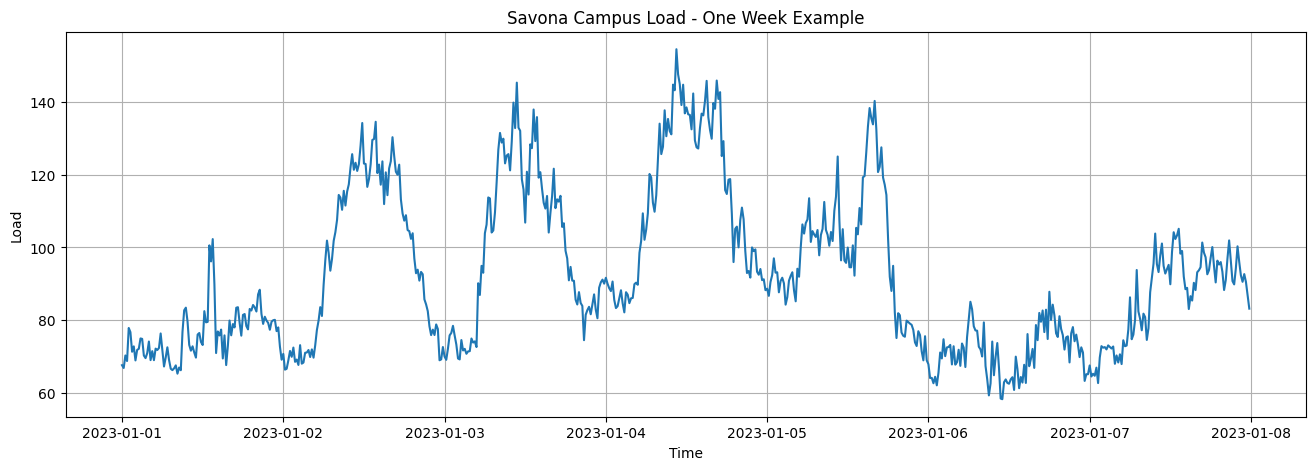

Number of records in selected week: 672
Missing values in selected week: 0


In [24]:
# Choose one week from the cleaned dataset
one_week = df_15min_clean.loc['2023-01-01':'2023-01-07']

plt.figure(figsize=(16, 5))
plt.plot(one_week.index, one_week['value'])
plt.title('Savona Campus Load - One Week Example')
plt.xlabel('Time')
plt.ylabel('Load')
plt.grid(True)
plt.show()

print("Number of records in selected week:", one_week.shape[0])
print("Missing values in selected week:", one_week['value'].isna().sum())

**3. Average Daily Load Pattern** shows:
- campus load behaves across the 24 hours

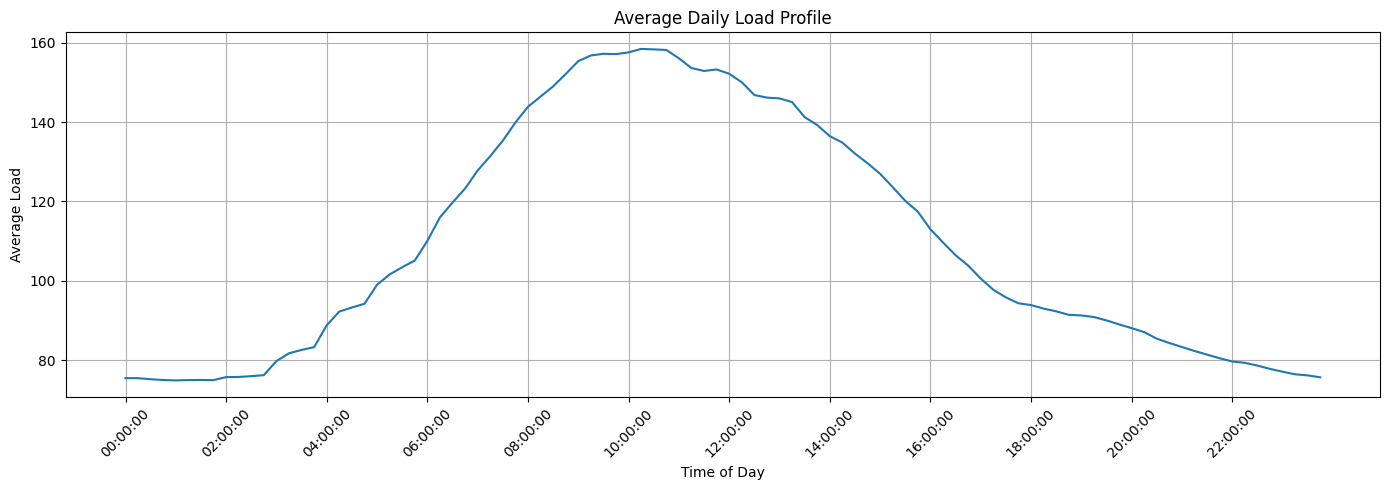

In [25]:
# Create a copy for analysis
eda_df = df_15min_clean.copy()

# Extract time of day
eda_df['time_of_day'] = eda_df.index.time

# Calculate average load for each 15-minute time slot
daily_profile = eda_df.groupby('time_of_day')['value'].mean()

# Plot average daily profile
plt.figure(figsize=(14, 5))
plt.plot(daily_profile.index.astype(str), daily_profile.values)
plt.title('Average Daily Load Profile')
plt.xlabel('Time of Day')
plt.ylabel('Average Load')
plt.xticks(range(0, len(daily_profile), 8), rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**4. Outlier Detection Using IQR Method**

Steps:

A. Find the "Middle Half": Q1(start point) , Q3(end point) , IQR(middle 50%)

B. Build a "Safety Fence": increase the range by multiplying the IQR by 1.5

C. Defining Outliers: Any data out of the range is considered as "Outlier"


In [26]:
# Step A: Finding the "Middle Half"
Q1 = df_15min_clean['value'].quantile(0.25)
Q3 = df_15min_clean['value'].quantile(0.75)
IQR = Q3 - Q1

# Step B: Build a "Safety Fence"
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step C: Defining Outliers
outliers = df_15min_clean[
    (df_15min_clean['value'] < lower_bound) |
    (df_15min_clean['value'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of outliers:", outliers.shape[0])
print("Percentage of outliers:", round(outliers.shape[0] / df_15min_clean.shape[0] * 100, 2), "%")

Q1: 69.44856914845833
Q3: 129.06016302960123
IQR: 59.611593881142895

Lower bound: -19.968821673256016
Upper bound: 218.47755385131558

Number of outliers: 13594
Percentage of outliers: 7.23 %


**5. Visualize Outliers over Time**

This plot highlights the outliers and high load over the time.
We can observe whether outliers are random spikes or seasonal patterns.

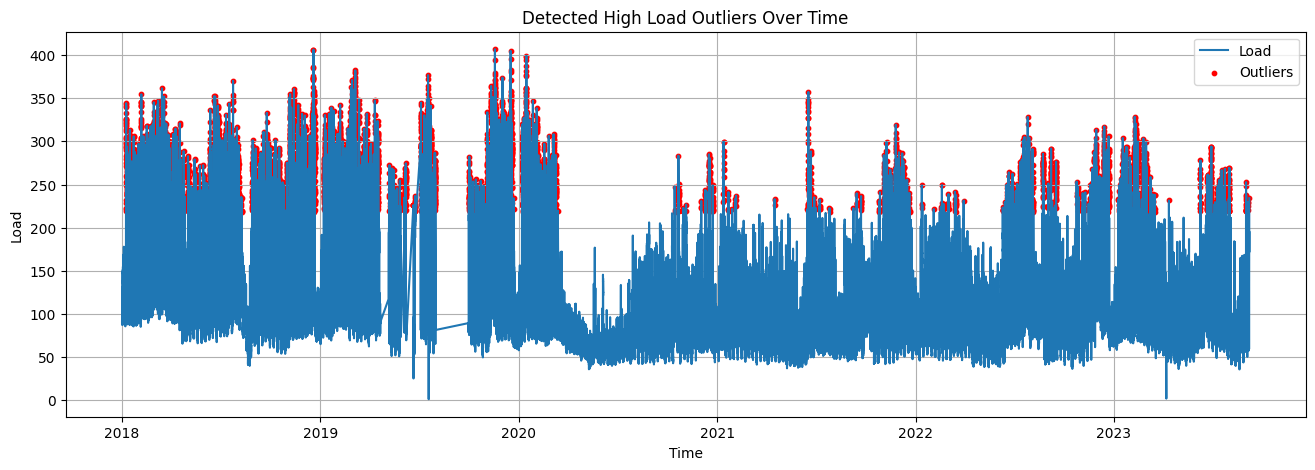

In [27]:
plt.figure(figsize=(16, 5))
# Plot normal load values
plt.plot(df_15min_clean.index, df_15min_clean['value'], label='Load')
# Highlight outliers with a specific color (e.g., red)
plt.scatter(outliers.index, outliers['value'], s=10, color='red', label='Outliers')
plt.title('Detected High Load Outliers Over Time')
plt.xlabel('Time')
plt.ylabel('Load')
plt.legend()
plt.grid(True)
plt.show()

**6. Monthly Outlier Distribution Analysis**

This visualization categorizes the identified outliers by month to identify seasonal trends or specific periods of high volatility.

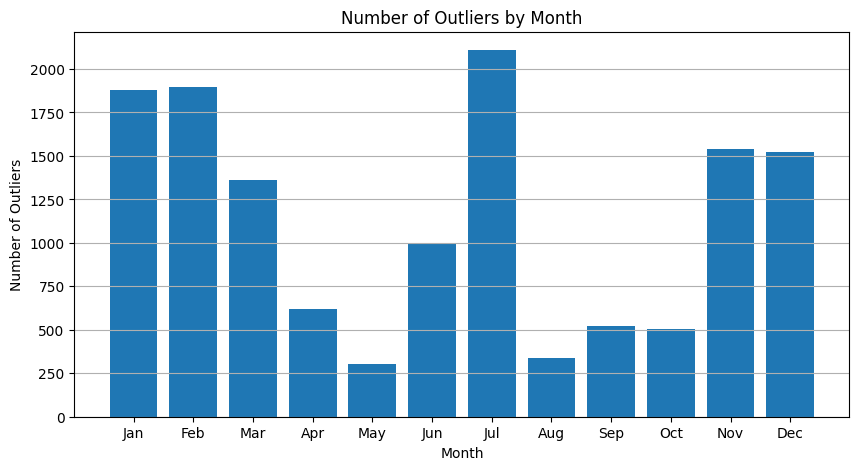

In [28]:
outliers_by_month = outliers.copy()
outliers_by_month['month'] = outliers_by_month.index.month
outlier_month_counts = outliers_by_month['month'].value_counts().sort_index()
short_months = [calendar.month_abbr[i] for i in outlier_month_counts.index]
plt.figure(figsize=(10, 5))
plt.bar(short_months, outlier_month_counts.values)
plt.title('Number of Outliers by Month')
plt.xlabel('Month')
plt.ylabel('Number of Outliers')
plt.grid(axis='y')
plt.show()

✅ The outliers in January, February, and July are likely caused by seasonal heating and cooling loads, so they are not true unusual values.


## **Feature Engineering**

**1. Time Features**

These features help the model learn:
- daily patterns
- weekly patterns
- seasonal/monthly behavior
- weekend vs working-day differences

In [29]:
# Create a modeling dataframe
model_df = df_15min_clean.copy()

# Time-based features
model_df['hour'] = model_df.index.hour
model_df['minute'] = model_df.index.minute
model_df['day_of_week'] = model_df.index.dayofweek
model_df['day_of_month'] = model_df.index.day
model_df['month'] = model_df.index.month
model_df['year'] = model_df.index.year

# Weekend feature
model_df['is_weekend'] = model_df['day_of_week'].isin([5, 6]).astype(int)

print("Model dataframe shape:", model_df.shape)

display(model_df.head())

Model dataframe shape: (188132, 8)


,value,hour,minute,day_of_week,day_of_month,month,year,is_weekend
data_timestamp,,,,,,,,
2017-12-31 23:00:00,91.015495,23,0,6,31,12,2017,1
2017-12-31 23:15:00,89.464928,23,15,6,31,12,2017,1
2017-12-31 23:30:00,88.188497,23,30,6,31,12,2017,1
2017-12-31 23:45:00,87.694330,23,45,6,31,12,2017,1
2018-01-01 00:00:00,90.413497,0,0,0,1,1,2018,0


**2. Lag Features**

These features help the model learn:
- lag_1 (15 min): Captures **immediate** momentum; if the value just went up 15 minutes ago, it’s likely to stay high now.
- lag_4 (1 hour): Captures **short-term** trends; helps the model understand the direction of change over the last hour.
- lag_96 (1 day): Captures **daily** periodicity; identifies patterns that repeat at the exact same time every day (*e.g., peak load at 2 PM*).
- lag_672 (1 week): Captures **weekly** periodicity; helps the model account for patterns that are specific to a certain day (*e.g., comparing this Monday at 10 AM to last Monday at 10 AM*).

In [30]:
# 15-minute data:
# 1 hour  = 4 time steps
# 1 day   = 96 time steps
# 1 week  = 672 time steps

model_df['lag_1'] = model_df['value'].shift(1)        # previous 15 minutes
model_df['lag_4'] = model_df['value'].shift(4)        # previous 1 hour
model_df['lag_96'] = model_df['value'].shift(96)      # previous day
model_df['lag_672'] = model_df['value'].shift(672)    # previous week

print("Model dataframe shape after lag features:", model_df.shape)

display(model_df.head(10))

print("\nMissing values created by lag features:")
print(model_df.isna().sum())

Model dataframe shape after lag features: (188132, 12)


,value,hour,minute,day_of_week,day_of_month,month,year,is_weekend,lag_1,lag_4,lag_96,lag_672
data_timestamp,,,,,,,,,,,,
2017-12-31 23:00:00,91.015495,23,0,6,31,12,2017,1,NaN,NaN,NaN,NaN
2017-12-31 23:15:00,89.464928,23,15,6,31,12,2017,1,91.015495,NaN,NaN,NaN
2017-12-31 23:30:00,88.188497,23,30,6,31,12,2017,1,89.464928,NaN,NaN,NaN
2017-12-31 23:45:00,87.694330,23,45,6,31,12,2017,1,88.188497,NaN,NaN,NaN
2018-01-01 00:00:00,90.413497,0,0,0,1,1,2018,0,87.694330,91.015495,NaN,NaN
2018-01-01 00:15:00,92.369405,0,15,0,1,1,2018,0,90.413497,89.464928,NaN,NaN
2018-01-01 00:30:00,92.542434,0,30,0,1,1,2018,0,92.369405,88.188497,NaN,NaN
2018-01-01 00:45:00,92.116210,0,45,0,1,1,2018,0,92.542434,87.694330,NaN,NaN
2018-01-01 01:00:00,94.260734,1,0,0,1,1,2018,0,92.116210,90.413497,NaN,NaN



Missing values created by lag features:
value             0
hour              0
minute            0
day_of_week       0
day_of_month      0
month             0
year              0
is_weekend        0
lag_1             1
lag_4             4
lag_96           96
lag_672         672
dtype: int64


**3. rolling Features**

These features help the model learn:
- rolling_mean_4 (1 hour): Represents the average intensity over the last hour
- rolling_mean_96 (1 day): Provides a baseline for the current day
- rolling_mean_672 (1 week): Captures the long-term average
- rolling_std_96 (1 day variability): Measures volatility or stability; a high value tells the model that the data was very "jumpy" over the last 24 hours, while a low value indicates a steady, predictable pattern

In [31]:
# Rolling means based on previous values
model_df['rolling_mean_4'] = model_df['value'].shift(1).rolling(window=4).mean()       # previous 1 hour
model_df['rolling_mean_96'] = model_df['value'].shift(1).rolling(window=96).mean()     # previous 1 day
model_df['rolling_mean_672'] = model_df['value'].shift(1).rolling(window=672).mean()   # previous 1 week

# Rolling standard deviation
model_df['rolling_std_96'] = model_df['value'].shift(1).rolling(window=96).std()       # previous 1 day variability

print("Model dataframe shape after rolling features:", model_df.shape)

display(model_df.head(10))

print("\nMissing values after rolling features:")
print(model_df.isna().sum())

Model dataframe shape after rolling features: (188132, 16)


,value,hour,minute,day_of_week,day_of_month,month,year,is_weekend,lag_1,lag_4,lag_96,lag_672,rolling_mean_4,rolling_mean_96,rolling_mean_672,rolling_std_96
data_timestamp,,,,,,,,,,,,,,,,
2017-12-31 23:00:00,91.015495,23,0,6,31,12,2017,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 23:15:00,89.464928,23,15,6,31,12,2017,1,91.015495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 23:30:00,88.188497,23,30,6,31,12,2017,1,89.464928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31 23:45:00,87.694330,23,45,6,31,12,2017,1,88.188497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:00:00,90.413497,0,0,0,1,1,2018,0,87.694330,91.015495,NaN,NaN,89.090813,NaN,NaN,NaN
2018-01-01 00:15:00,92.369405,0,15,0,1,1,2018,0,90.413497,89.464928,NaN,NaN,88.940313,NaN,NaN,NaN
2018-01-01 00:30:00,92.542434,0,30,0,1,1,2018,0,92.369405,88.188497,NaN,NaN,89.666432,NaN,NaN,NaN
2018-01-01 00:45:00,92.116210,0,45,0,1,1,2018,0,92.542434,87.694330,NaN,NaN,90.754917,NaN,NaN,NaN
2018-01-01 01:00:00,94.260734,1,0,0,1,1,2018,0,92.116210,90.413497,NaN,NaN,91.860387,NaN,NaN,NaN



Missing values after rolling features:
value                 0
hour                  0
minute                0
day_of_week           0
day_of_month          0
month                 0
year                  0
is_weekend            0
lag_1                 1
lag_4                 4
lag_96               96
lag_672             672
rolling_mean_4        4
rolling_mean_96      96
rolling_mean_672    672
rolling_std_96       96
dtype: int64


In [32]:
# ==========================================
# REMOVE ROWS WITH MISSING FEATURE VALUES
# ==========================================

print("Shape before removing NaN feature rows:", model_df.shape)

print("\nMissing values before removal:")
print(model_df.isna().sum())

# Remove rows with any missing values
model_df = model_df.dropna().copy()

print("\nShape after removing NaN feature rows:", model_df.shape)

print("\nMissing values after removal:")
print(model_df.isna().sum())

display(model_df.head())

Shape before removing NaN feature rows: (188132, 16)

Missing values before removal:
value                 0
hour                  0
minute                0
day_of_week           0
day_of_month          0
month                 0
year                  0
is_weekend            0
lag_1                 1
lag_4                 4
lag_96               96
lag_672             672
rolling_mean_4        4
rolling_mean_96      96
rolling_mean_672    672
rolling_std_96       96
dtype: int64

Shape after removing NaN feature rows: (187460, 16)

Missing values after removal:
value               0
hour                0
minute              0
day_of_week         0
day_of_month        0
month               0
year                0
is_weekend          0
lag_1               0
lag_4               0
lag_96              0
lag_672             0
rolling_mean_4      0
rolling_mean_96     0
rolling_mean_672    0
rolling_std_96      0
dtype: int64


,value,hour,minute,day_of_week,day_of_month,month,year,is_weekend,lag_1,lag_4,lag_96,lag_672,rolling_mean_4,rolling_mean_96,rolling_mean_672,rolling_std_96
data_timestamp,,,,,,,,,,,,,,,,
2018-01-07 23:00:00,99.156964,23,0,6,7,1,2018,1,101.341195,101.720466,93.093490,91.015495,102.081163,105.195796,117.757025,12.115811
2018-01-07 23:15:00,97.011384,23,15,6,7,1,2018,1,99.156964,100.850359,92.761515,89.464928,101.440287,105.258957,117.769140,12.067765
2018-01-07 23:30:00,94.124272,23,30,6,7,1,2018,1,97.011384,104.412631,91.591699,88.188497,100.480543,105.303227,117.780370,12.029170
2018-01-07 23:45:00,97.969241,23,45,6,7,1,2018,1,94.124272,101.341195,92.407258,87.694330,97.908453,105.329607,117.789203,12.001529
2018-01-08 00:00:00,99.872620,0,0,0,8,1,2018,0,97.969241,99.156964,89.589749,90.413497,97.065465,105.387545,117.804493,11.951812


✅**model_df** is the final dataset and ready for splitting

## **Splitting Data to Train and Test**

**1. Define Features and Target**

*value* is target which will be forcasted.

other columns are features for model to learn.

In [33]:
# Target variable
y = model_df['value']

# Input features
X = model_df.drop(columns=['value'])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (187460, 15)
Target vector shape: (187460,)


,hour,minute,day_of_week,day_of_month,month,year,is_weekend,lag_1,lag_4,lag_96,lag_672,rolling_mean_4,rolling_mean_96,rolling_mean_672,rolling_std_96
data_timestamp,,,,,,,,,,,,,,,
2018-01-07 23:00:00,23,0,6,7,1,2018,1,101.341195,101.720466,93.093490,91.015495,102.081163,105.195796,117.757025,12.115811
2018-01-07 23:15:00,23,15,6,7,1,2018,1,99.156964,100.850359,92.761515,89.464928,101.440287,105.258957,117.769140,12.067765
2018-01-07 23:30:00,23,30,6,7,1,2018,1,97.011384,104.412631,91.591699,88.188497,100.480543,105.303227,117.780370,12.029170
2018-01-07 23:45:00,23,45,6,7,1,2018,1,94.124272,101.341195,92.407258,87.694330,97.908453,105.329607,117.789203,12.001529
2018-01-08 00:00:00,0,0,0,8,1,2018,0,97.969241,99.156964,89.589749,90.413497,97.065465,105.387545,117.804493,11.951812


,value
data_timestamp,
2018-01-07 23:00:00,99.156964
2018-01-07 23:15:00,97.011384
2018-01-07 23:30:00,94.124272
2018-01-07 23:45:00,97.969241
2018-01-08 00:00:00,99.872620


**2. Time-Based Train/Test Split**

For time-series forecasting, we should *not use random splitting* because it mixes past and future data.
> Instead, we **train on earlier data** and **test on later data**.

In [34]:
# Use 80% of the data for training and 20% for testing
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

Training set size: (149968, 15)
Testing set size: (37492, 15)

Training period:
2018-01-07 23:00:00 to 2022-08-11 19:15:00

Testing period:
2022-08-11 19:30:00 to 2023-09-07 08:30:00


## **Baseline Forecasting Model**

A baseline is important because every advanced model should perform better than this simple reference.
> **Previous Week Load**:
> This baseline predicts each load value using the load from the same time one week earlier.

In [38]:
# Baseline prediction: same time previous week
baseline_pred = model_df['lag_672'].iloc[split_index:]

# Actual test values
baseline_actual = y_test

# Evaluation metrics
baseline_mae = mean_absolute_error(baseline_actual, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actual, baseline_pred))
baseline_mape = mean_absolute_percentage_error(baseline_actual, baseline_pred) * 100

print("Baseline Model: Previous Week Load")
print("----------------------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape, "%")

Baseline Model: Previous Week Load
----------------------------------
MAE : 21.18893098753456
RMSE: 34.34982945923099
MAPE: 20.763394890621907 %


## **Random Forest Model**

**1. Training the Model**

In [40]:
# Define model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**2. Evaluating the Model**

The performance of the Random Forest is qualified by following error metrics:

- *Mean Absolute Error* (MAE): Represents the average magnitude of the errors in a set of predictions, without considering their direction.
- *Root Mean Squared Error* (RMSE): The square root of the average of squared differences between prediction and actual observation.
- *Mean Absolute Percentage Error* (MAPE): Measures the size of the error in percentage terms. It is particularly useful for understanding the error relative to the scale of the data.

In [42]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100

print("Random Forest Model")
print("-------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape, "%")

Random Forest Model
-------------------
MAE : 5.208380203454875
RMSE: 7.911135931967271
MAPE: 5.140997101515537 %


## **XGBOOST Model**

**1. Training Model**

In [43]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict on test set
xgb_pred = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**2. Evaluating the Model**

The performance of XGBoost is qualified by same error metrics.

In [44]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print("XGBoost Model")
print("-------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape, "%")

XGBoost Model
-------------
MAE : 5.097155085701559
RMSE: 7.7467567414715885
MAPE: 4.987964444454637 %


## **LightGBM Model**

**1. Training Model**

In [45]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train model
lgbm_model.fit(X_train, y_train)

# Predict on test set
lgbm_pred = lgbm_model.predict(X_test)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022922 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2128
[LightGBM] [Info] Number of data points in the train set: 149968, number of used features: 15
[LightGBM] [Info] Start training from score 111.052216
LightGBM model trained successfully.


**2. Evaluating the Model**

The performance of LightGBM is qualified by same error metrics.

In [46]:
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_mape = mean_absolute_percentage_error(y_test, lgbm_pred) * 100

print("LightGBM Model")
print("--------------")
print("MAE :", lgbm_mae)
print("RMSE:", lgbm_rmse)
print("MAPE:", lgbm_mape, "%")

LightGBM Model
--------------
MAE : 5.069608571554892
RMSE: 7.69915223569935
MAPE: 4.9713323320156055 %


## **Model Comparision**

In [72]:
model_comparison = pd.DataFrame({
    'Model': [
        'Previous Week Baseline',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'MAE': [
        baseline_mae,
        rf_mae,
        xgb_mae,
        lgbm_mae
    ],
    'RMSE': [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse
    ],
    'MAPE (%)': [
        baseline_mape,
        rf_mape,
        xgb_mape,
        lgbm_mape
    ]
})

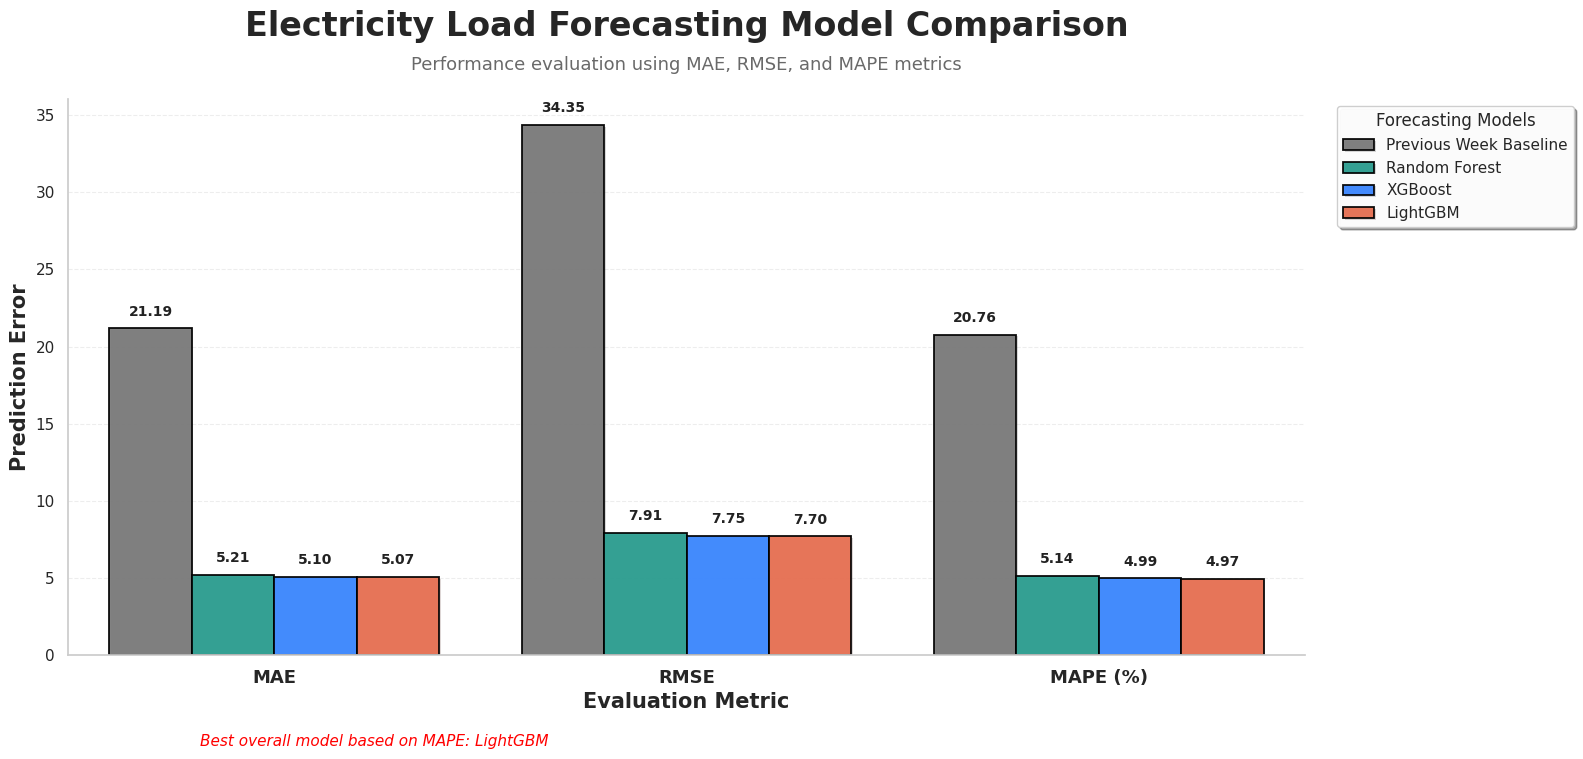

In [73]:
# STYLE
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 8))

# RESHAPE DATA
df_melted = model_comparison.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Value'
)

# COLOR PALETTE
palette = {
    'Previous Week Baseline': '#7A7A7A',  # Gray
    'Random Forest': '#2A9D8F',           # Teal
    'XGBoost': '#3A86FF',                 # Blue
    'LightGBM': '#E76F51'                 # Orange
}

# PLOT
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Value',
    hue='Model',
    palette=palette,
    saturation=1.0,
    edgecolor='black',
    linewidth=1.3
)

# BAR STYLING
for bar in ax.patches:
    bar.set_alpha(0.94)
    bar.set_path_effects([
        pe.withSimplePatchShadow(
            offset=(1.2, -1.2),
            alpha=0.18
        )
    ])

# GRID & AXES
ax.grid(axis='y',linestyle='--',linewidth=0.8,alpha=0.35)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# TITLES
ax.text(
    0.5, 1.10,
    'Electricity Load Forecasting Model Comparison',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=24,
    fontweight='bold'
)
ax.text(
    0.5, 1.045,
    'Performance evaluation using MAE, RMSE, and MAPE metrics',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=13,
    color='dimgray'
)

# LABELS
plt.xlabel(
    'Evaluation Metric',
    fontsize=15,
    fontweight='bold'
)
plt.ylabel(
    'Prediction Error',
    fontsize=15,
    fontweight='bold'
)

# LEGEND
legend = plt.legend(
    title='Forecasting Models',
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.96)

# VALUE LABELS

for p in ax.patches:
    height = p.get_height()

    # Skip empty / zero-height bars
    if height <= 0 or pd.isna(height):
        continue

    ax.annotate(
        f'{height:.2f}',
        (
            p.get_x() + p.get_width() / 2.,
            height
        ),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#222222',
        xytext=(0, 7),
        textcoords='offset points'
    )

# TICKS
plt.xticks(
    fontsize=13,
    fontweight='bold'
)

plt.yticks(fontsize=11)

# BEST MODEL NOTE
best_model = model_comparison.sort_values('MAPE (%)').iloc[0]['Model']

plt.figtext(
    0.13,
    -0.02,
    f'Best overall model based on MAPE: {best_model}',
    fontsize=11,
    style='italic',
    color='red'
)

# LAYOUT
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Among the tested models, LightGBM achieved the best performance, with a MAE of 5.07, RMSE of 7.70, and MAPE of 4.97%. Compared with the previous-week baseline model, which obtained a MAPE of 20.76%, LightGBM reduced the forecasting error substantially. This confirms that machine-learning models using time-based, lag, and rolling-window features can effectively capture the temporal patterns of campus electrical load.




> **Best Model** is **LightGBM** for this task ✅



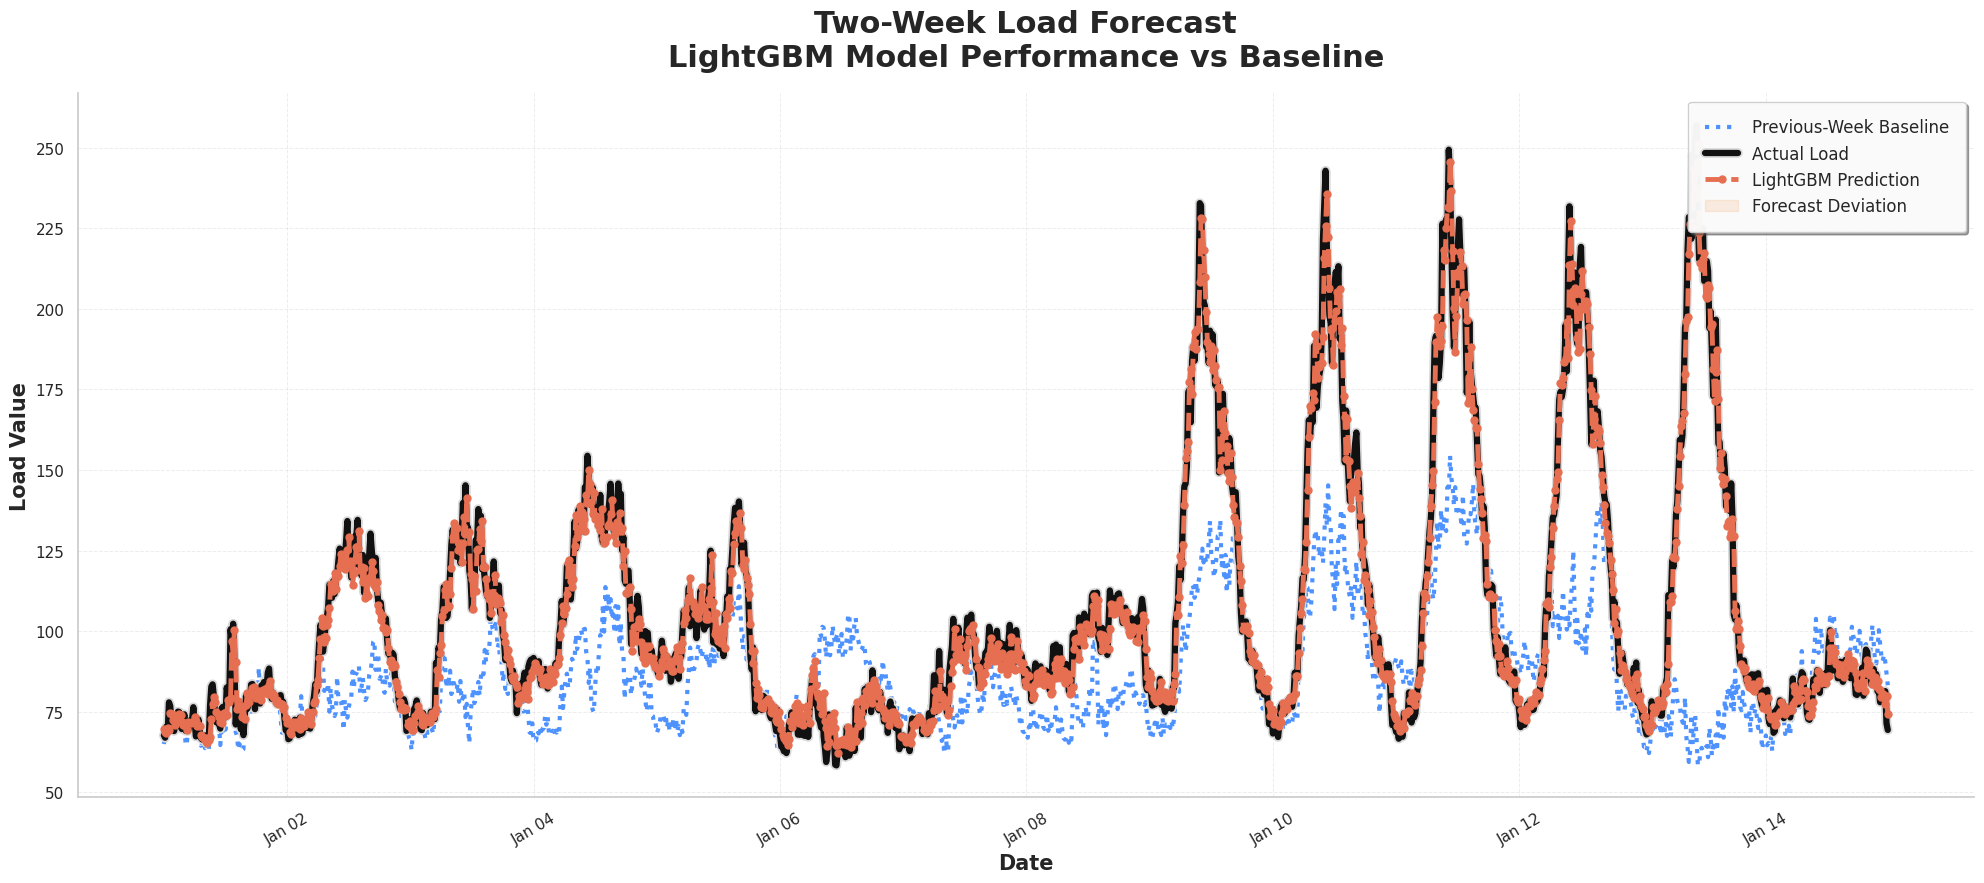

In [55]:
# Visualize Predictions on Actual Data
comparison_results = pd.DataFrame({
    'actual': y_test,
    'lightgbm_prediction': lgbm_pred,
    'baseline_week_prediction': baseline_pred
}, index=y_test.index)
two_weeks = comparison_results.loc['2023-01-01':'2023-01-14']

# Style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(20, 9))
colors = {
    'actual': '#111111',      # Rich black
    'lightgbm': '#E76F51',    # Modern coral/orange
    'baseline': '#3A86FF',    # Vibrant blue
    'fill': '#F4A261'         # Soft orange fill
}
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Baseline
baseline_line = ax.plot(
    two_weeks.index,
    two_weeks['baseline_week_prediction'],
    label='Previous-Week Baseline',
    color=colors['baseline'],
    linewidth=3.0,
    linestyle=':',
    alpha=0.9,
    zorder=1)[0]

# Actual
actual_line = ax.plot(
    two_weeks.index,
    two_weeks['actual'],
    label='Actual Load',
    color=colors['actual'],
    linewidth=4.5,
    zorder=3)[0]
actual_line.set_path_effects([
    pe.Stroke(linewidth=7, foreground='0.85'),
    pe.Normal()
])

# LightGBM Prediction
pred_line = ax.plot(
    two_weeks.index,
    two_weeks['lightgbm_prediction'],
    label='LightGBM Prediction',
    color=colors['lightgbm'],
    linewidth=3.5,
    linestyle='--',
    marker='o',
    markersize=5,
    zorder=4)[0]

# Forecast Error Area
ax.fill_between(
    two_weeks.index,
    two_weeks['actual'],
    two_weeks['lightgbm_prediction'],
    color=colors['fill'],
    alpha=0.18,
    label='Forecast Deviation',
    zorder=2
)

# Date Formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

# Titles & Labels
plt.title(
    'Two-Week Load Forecast\nLightGBM Model Performance vs Baseline',
    fontsize=22,
    fontweight='bold',
    pad=20
)
plt.ylabel('Load Value', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=15, fontweight='bold')

# Legend
legend = plt.legend(
    loc='upper right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=1
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
plt.tight_layout()
plt.show()

## **Feature Importance**

**LightGBM Feature Importance**

- LightGBM feature importance shows that the most influential variable was `lag_1`, meaning the previous 15-minute load value was the strongest predictor. The `hour` feature was also highly important, confirming the strong effect of time-of-day patterns on campus electricity demand.
- The features `lag_96` and `lag_672` were also important, showing that the model captured daily and weekly seasonality. Rolling features such as `rolling_mean_4`, `rolling_mean_672`, and `rolling_std_96` helped the model learn recent trends and load variability.

Overall, the results show that recent load history, daily patterns, weekly patterns, and time-of-day behavior were the key drivers of the LightGBM forecast.

In [74]:
# Create feature importance dataframe
feature_importance_lgbm = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_model.feature_importances_
})

# Sort by importance
feature_importance_lgbm = feature_importance_lgbm.sort_values(
    by='importance',
    ascending=False
)

display(feature_importance_lgbm)

,feature,importance
7,lag_1,2138
0,hour,1943
9,lag_96,1432
10,lag_672,1294
11,rolling_mean_4,1281
8,lag_4,1231
13,rolling_mean_672,1063
14,rolling_std_96,1005
12,rolling_mean_96,911
4,month,716
